In [1]:
import pathlib

import pandas as pd

In [36]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

In [2]:
output_folder = pathlib.Path("../data/outputs/")

In [3]:
def get_scores(folder: pathlib.Path) -> pd.DataFrame | None:
    scores = {}
    scores_file = folder / "scores.csv"
    if not scores_file.is_file():
        return None
    scores_df = pd.read_csv(scores_file, index_col=0)
    return scores_df

In [4]:
scores_data_list = []
untrained_data_list = []
for category in output_folder.iterdir():
    if not category.is_dir():
        continue
    for name in category.iterdir():
        if not name.is_dir():
            continue
        scores_df = get_scores(name)
        if scores_df is None:
            untrained_data_list.append({
                "category": category,
                "name": name,
            })
        else:
            scores_data_list.append(scores_df)

untrained_df = pd.DataFrame(untrained_data_list)
all_scores_df = pd.concat(scores_data_list)

In [6]:
untrained_df

,category,name
0,..\data\outputs\carbon_source,..\data\outputs\carbon_source\asparagine
1,..\data\outputs\carbon_source,..\data\outputs\carbon_source\fucose
2,..\data\outputs\carbon_source,..\data\outputs\carbon_source\histidine
3,..\data\outputs\carbon_source,..\data\outputs\carbon_source\leucine
4,..\data\outputs\carbon_source,..\data\outputs\carbon_source\ornithine
5,..\data\outputs\carbon_source,..\data\outputs\carbon_source\proline
6,..\data\outputs\carbon_source,..\data\outputs\carbon_source\threonine
7,..\data\outputs\unknown,..\data\outputs\unknown\ncbi_tax_id-subspecies
8,..\data\outputs\unknown,..\data\outputs\unknown\unnamed_13


In [5]:
all_scores_df

,name,category,accuracy,balanced_accuracy,f1,precision,recall,matthews_corrcoef
acetate-assimilation,acetate,assimilation,0.739130,0.739130,0.739130,0.739130,0.739130,0.478261
adipate-assimilation,adipate,assimilation,0.815508,0.822296,0.634921,0.512821,0.833333,0.548144
cellobiose-assimilation,cellobiose,assimilation,0.574468,0.570000,0.523810,0.550000,0.500000,0.141290
citrate-assimilation,citrate,assimilation,0.718654,0.723243,0.710692,0.660819,0.768707,0.444674
D-fructose-assimilation,D-fructose,assimilation,0.720000,0.743633,0.740741,0.869565,0.645161,0.474546
...,...,...,...,...,...,...,...,...
triphenyltetrazolium_chloride-reduction,triphenyltetrazolium_chloride,reduction,0.538462,0.512500,0.400000,0.400000,0.400000,0.025000
gram_positive-unknown,gram_positive,unknown,0.979943,0.981428,0.972621,0.958869,0.986772,0.957046
motility-unknown,motility,unknown,0.833158,0.833745,0.824697,0.807775,0.842342,0.666203
oxygen_tolerance_aerobe-unknown,oxygen_tolerance_aerobe,unknown,0.935657,0.880108,0.963746,0.978528,0.949405,0.684778


In [8]:
all_scores_melt = all_scores_df.melt(id_vars=["name", "category"], var_name='score', value_name='value')
all_scores_melt

,name,category,score,value
0,acetate,assimilation,accuracy,0.739130
1,adipate,assimilation,accuracy,0.815508
2,cellobiose,assimilation,accuracy,0.574468
3,citrate,assimilation,accuracy,0.718654
4,D-fructose,assimilation,accuracy,0.720000
...,...,...,...,...
1465,triphenyltetrazolium_chloride,reduction,matthews_corrcoef,0.025000
1466,gram_positive,unknown,matthews_corrcoef,0.957046
1467,motility,unknown,matthews_corrcoef,0.666203
1468,oxygen_tolerance_aerobe,unknown,matthews_corrcoef,0.684778


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

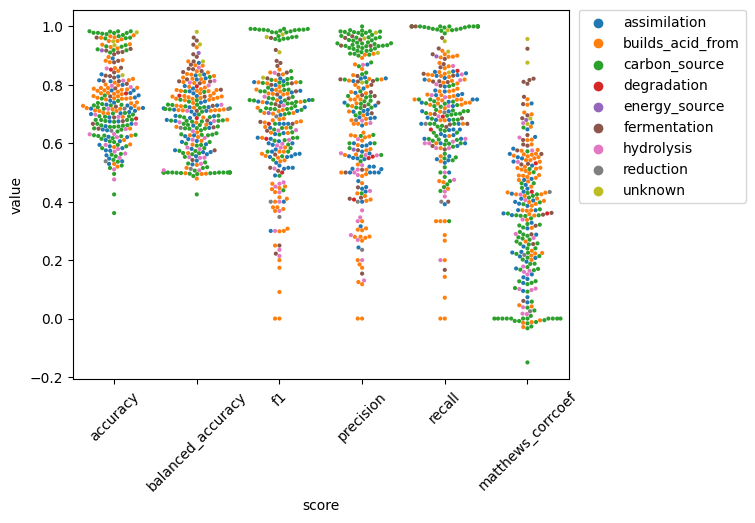

In [19]:
sns.swarmplot(data=all_scores_melt, x="score", y="value", hue="category", size=3)
plt.xticks(rotation=45);
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0);

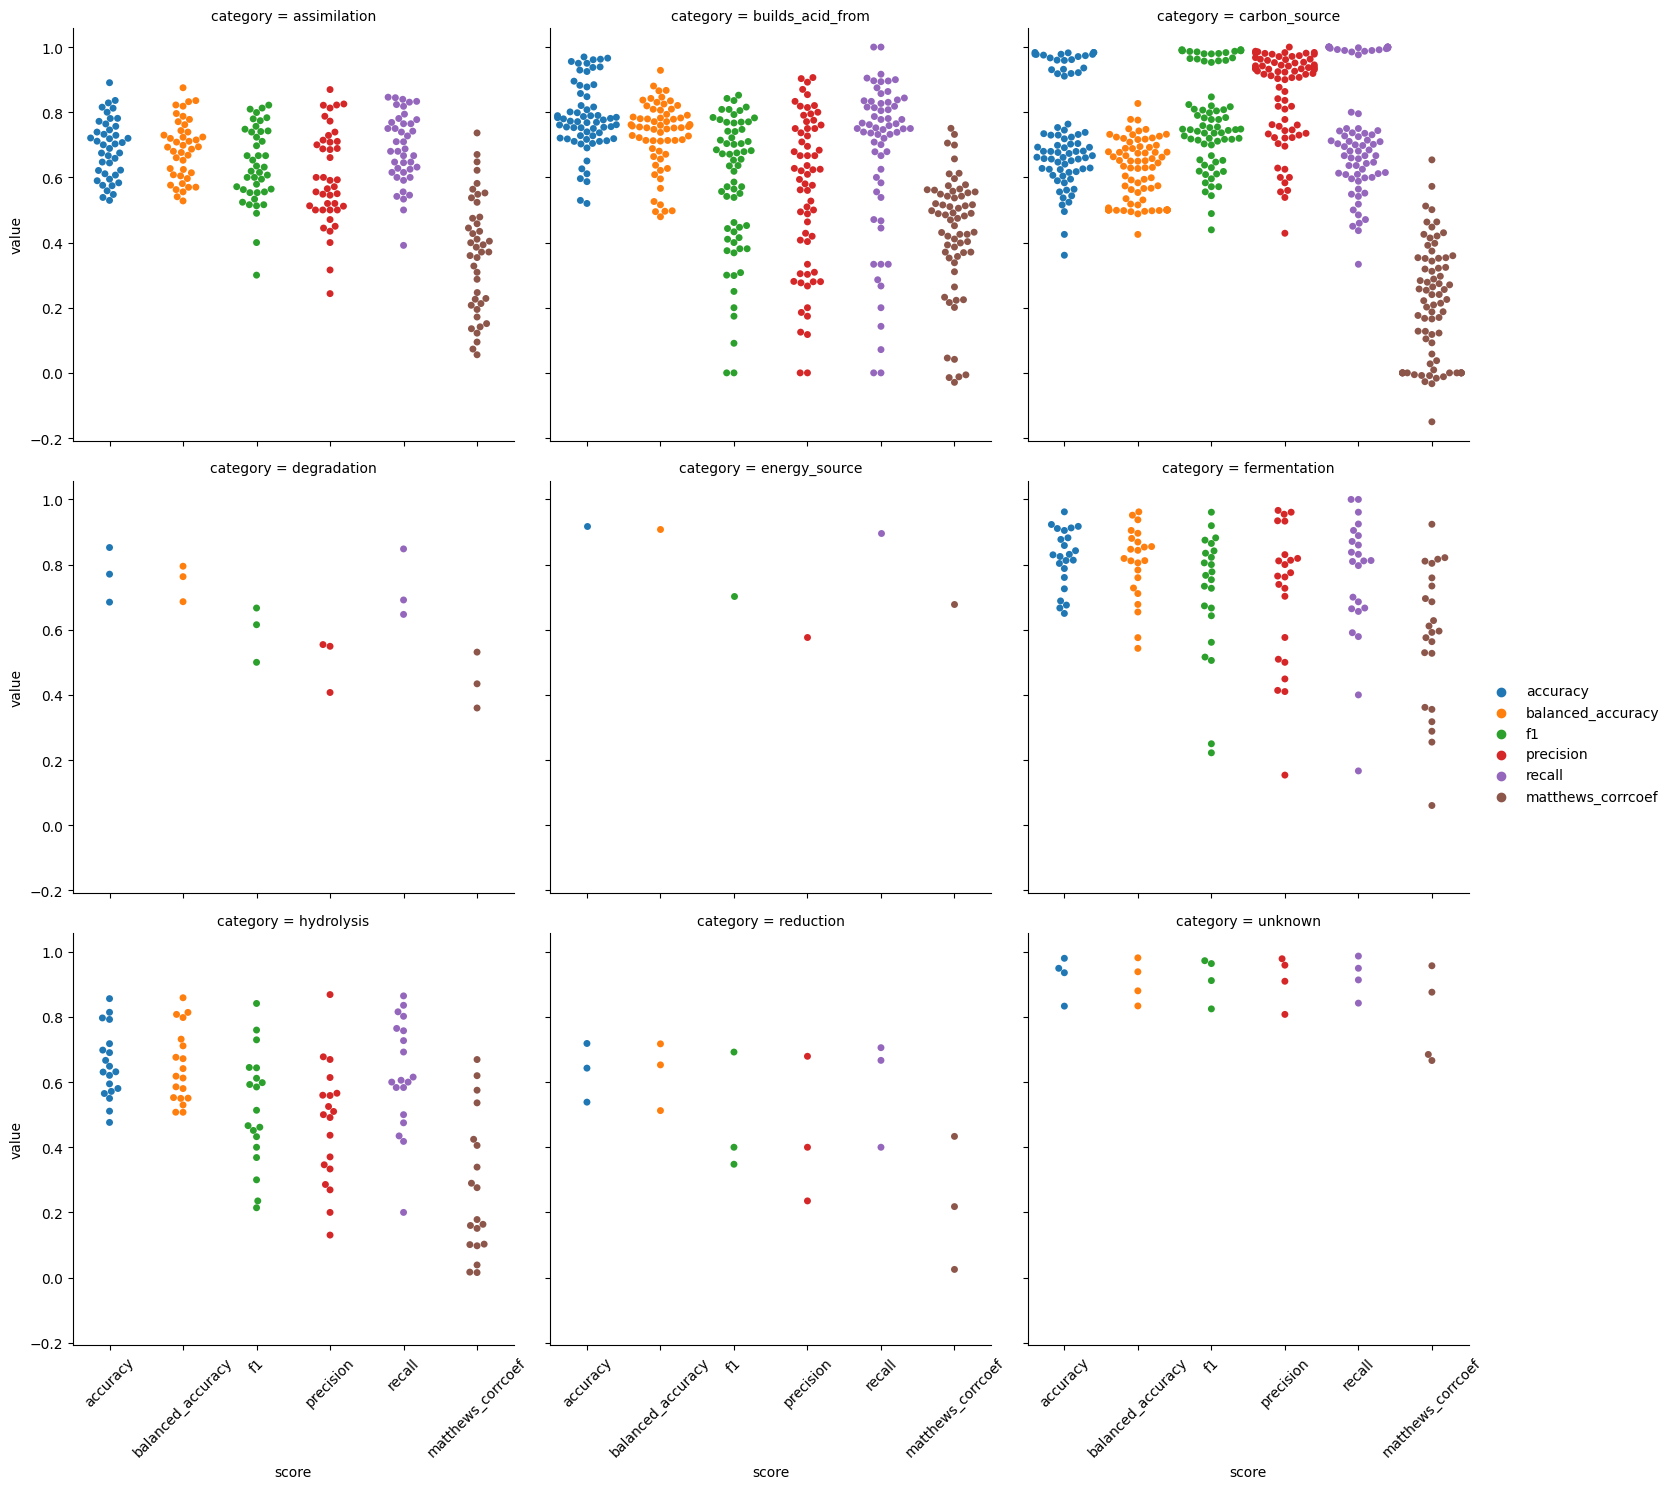

In [37]:
g = sns.catplot(data=all_scores_melt, x="score", y="value", hue="score", col="category", kind="swarm",  col_wrap=3)
for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=45, which="both");
g.figure.tight_layout();
g.add_legend();

In [39]:
top20_scores_df = all_scores_df.sort_values(by=["matthews_corrcoef", "balanced_accuracy"], ascending=[False, False]).head(20)
top20_scores_df

,name,category,accuracy,balanced_accuracy,f1,precision,recall,matthews_corrcoef
gram_positive-unknown,gram_positive,unknown,0.979943,0.981428,0.972621,0.958869,0.986772,0.957046
L-rhamnose-fermentation,L-rhamnose,fermentation,0.961905,0.961874,0.960784,0.960784,0.960784,0.923747
spore_formation-unknown,spore_formation,unknown,0.949219,0.938570,0.911565,0.909502,0.913636,0.875953
D-mannitol-fermentation,D-mannitol,fermentation,0.912548,0.896106,0.882051,0.966292,0.811321,0.821249
myo-inositol-fermentation,myo-inositol,fermentation,0.910714,0.937500,0.864865,0.761905,1.000000,0.816497
cellobiose-fermentation,cellobiose,fermentation,0.923077,0.951613,0.842105,0.727273,1.000000,0.810488
L-arabinose-fermentation,L-arabinose,fermentation,0.904762,0.904762,0.919355,0.934426,0.904762,0.803773
melibiose-fermentation,melibiose,fermentation,0.877193,0.880297,0.875000,0.830508,0.924528,0.759186
D-xylose-builds_acid_from,D-xylose,builds_acid_from,0.877622,0.880429,0.852321,0.814516,0.893805,0.750580
decanoate-assimilation,decanoate,assimilation,0.890667,0.875202,0.812785,0.787611,0.839623,0.736434


In [41]:
top20_scores_df.groupby("category")["name"].count()

category
assimilation        2
builds_acid_from    4
energy_source       1
fermentation        9
hydrolysis          1
unknown             3
Name: name, dtype: int64

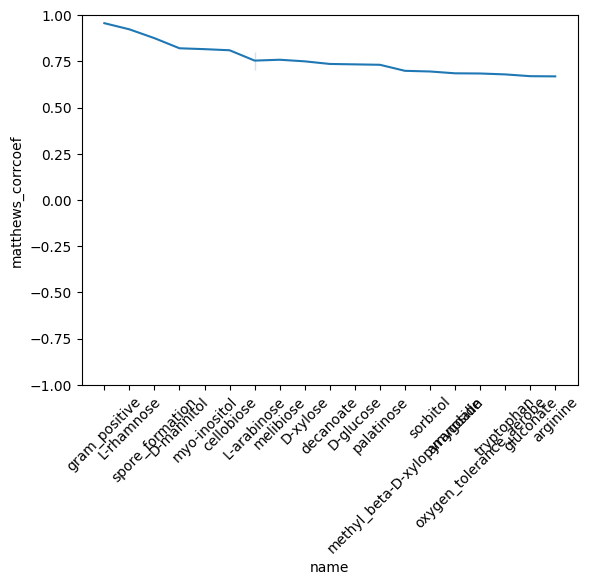

In [47]:
sns.lineplot(data=top20_scores_df, x="name", y="matthews_corrcoef")
plt.ylim((-1, 1))
plt.xticks(rotation=45);

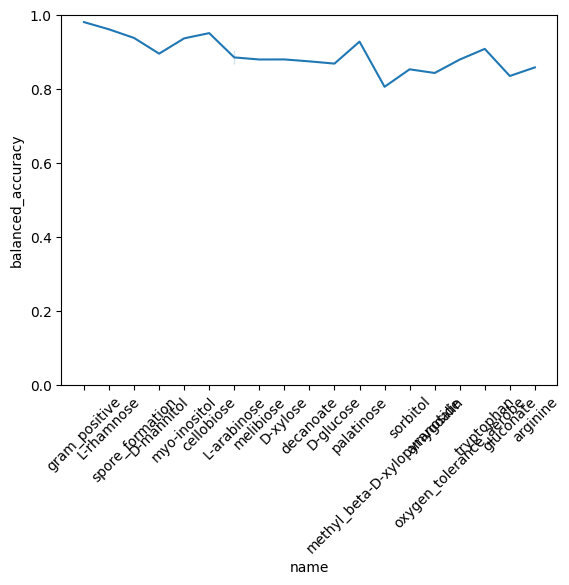

In [48]:
sns.lineplot(data=top20_scores_df, x="name", y="balanced_accuracy")
plt.ylim((0, 1))
plt.xticks(rotation=45);